# Pandas: tabelas, filtros e agregações

Este notebook apresenta um fluxo pequeno e completo com Pandas:
- criação de `Series` e `DataFrame`;
- seleção por coluna e por linha;
- filtros booleanos;
- criação e transformação de colunas;
- estatísticas, `groupby` e tratamento de ausentes;
- leitura e escrita simples sem depender de arquivos externos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Criando uma Series

In [5]:
serie_notas = pd.Series([8.5, 7.0, 9.0], index=["Ana", "Bruno", "Carla"])
print(serie_notas)

Ana      8.5
Bruno    7.0
Carla    9.0
dtype: float64


## 2. Criando um DataFrame

In [40]:
df = pd.DataFrame({
    "aluno": ["Ana", "Bruno", "Carla", "Diego", "Eva"],
    "turma": ["A", "A", "B", "B", "A"],
    "nota": [8.5, 7.0, 9.0, np.nan, 6.0],
    "faltas": [2, 5, 1, 4, 6], 
    })
df

,aluno,turma,nota,faltas
0,Ana,A,8.5,2
1,Bruno,A,7.0,5
2,Carla,B,9.0,1
3,Diego,B,NaN,4
4,Eva,A,6.0,6


## 3. Seleção por coluna e por linha

In [19]:
print("Coluna nota:")
print(df["nota"])

print("\nLinhas 0 a 2 com aluno e nota:")
print(df.loc[0:2, ["aluno", "nota"]])

print("\nLinhas 2 em diante, da coluna turma para frente:")
print(df.iloc[2:, 1:])

Coluna nota:
0    8.5
1    7.0
2    9.0
3    NaN
4    6.0
Name: nota, dtype: float64

Linhas 0 a 2 com aluno e nota:
   aluno  nota
0    Ana   8.5
1  Bruno   7.0
2  Carla   9.0

Linhas 2 em diante, da coluna turma para frente:
  turma  nota  faltas
2     B   9.0       1
3     B   NaN       4
4     A   6.0       6


## 4. Filtros booleanos

In [26]:
aprovados = df[df["nota"] >= 7.0]
baixa_frequencia = df[df["faltas"] > 4]

print("Aprovados:\n", aprovados)
print("\nMais de 4 faltas:\n", baixa_frequencia)

Aprovados:
    aluno turma  nota  faltas
0    Ana     A   8.5       2
1  Bruno     A   7.0       5
2  Carla     B   9.0       1

Mais de 4 faltas:
    aluno turma  nota  faltas
1  Bruno     A   7.0       5
4    Eva     A   6.0       6


## 5. Tratando valores ausentes e criando colunas

In [57]:
#media_notas = df["nota"].mean()

df["nota"] = df["nota"].fillna(media_notas)
df["situacao"] = np.where(df["nota"] >= 7.0, "Aprovado", "Recuperacao")
df["nota_ajustada"] = df["nota"] + 0.5
df["frequencia"] = 100 - df["faltas"] 
df

,aluno,turma,nota,faltas,situacao,nota_ajustada,frequencia
0,Ana,A,8.500,2,Aprovado,9.000,98
1,Bruno,A,7.000,5,Aprovado,7.500,95
2,Carla,B,9.000,1,Aprovado,9.500,99
3,Diego,B,7.625,4,Aprovado,8.125,96
4,Eva,A,6.000,6,Recuperacao,6.500,94


## 6. Estatísticas e agregações

In [65]:
#print("Media geral:", df["nota"].mean())

#print("Maior nota:", df["nota"].max())
print("Resumo numerico:\n", df[["nota", "faltas", "frequencia"]].describe())


Resumo numerico:
            nota    faltas  frequencia
count  5.000000  5.000000    5.000000
mean   7.625000  3.600000   96.400000
std    1.192424  2.073644    2.073644
min    6.000000  1.000000   94.000000
25%    7.000000  2.000000   95.000000
50%    7.625000  4.000000   96.000000
75%    8.500000  5.000000   98.000000
max    9.000000  6.000000   99.000000


## 7. Groupby por turma

In [69]:
resumo_turmas = df.groupby("turma").agg({
    "nota": ["mean", "max"],
    "faltas": ["sum", "mean"]
})
resumo_turmas

nota      faltas          
           mean  max    sum      mean
turma                                
A      7.166667  8.5     13  4.333333
B      8.312500  9.0      5  2.500000

## 8. Leitura e escrita simples

In [73]:
# Salvar o DataFrame df em um arquivo CSV
df.to_csv("dados.csv", index=False)

# Ler o arquivo CSV salvo e armazenar em df_1
df_1 = pd.read_csv("dados.csv")

df_1

,aluno,turma,nota,faltas,situacao,nota_ajustada,frequencia
0,Ana,A,8.500,2,Aprovado,9.000,98
1,Bruno,A,7.000,5,Aprovado,7.500,95
2,Carla,B,9.000,1,Aprovado,9.500,99
3,Diego,B,7.625,4,Aprovado,8.125,96
4,Eva,A,6.000,6,Recuperacao,6.500,94


## 9. Fluxo Completo

Vamos produzir um quadro resumido apenas com as colunas mais úteis para análise.

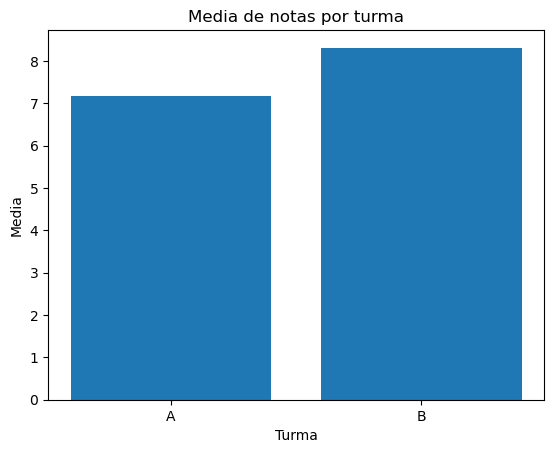

In [36]:
media_por_turma = df.groupby('turma')['nota'].mean()

plt.bar(media_por_turma.index, media_por_turma.values)
plt.title('Media de notas por turma')
plt.xlabel('Turma')
plt.ylabel('Media')
plt.show()

## 10. Usando o Pandas para obter um resultado semelhante: 

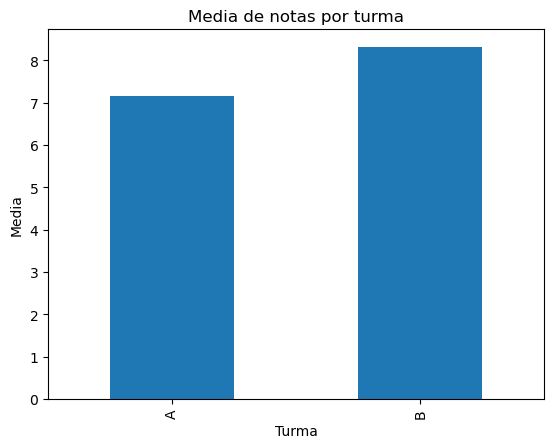

In [83]:
media_por_turma = df.groupby('turma')['nota'].mean()
media_por_turma.plot(kind='bar')

plt.title('Media de notas por turma')
plt.xlabel('Turma')
plt.ylabel('Media')
plt.show()